In [3]:
import numpy as np
import pandas as pd

def generate_data(n_samples=1000, intervention=None):
    # Exogenous noise variables
    U_X = np.random.normal(0, 1, n_samples)
    U_Y = np.random.normal(0, 1, n_samples)
    U_Z = np.random.normal(0, 1, n_samples)

    # Structural assignments
    X = U_X

    if intervention == 'Y=5':
        Y = np.full(n_samples, 5.0)  # Mutilated assignment
    else:
        Y = 2 * X + U_Y              # Observational assignment

    Z = Y + 3 * X + U_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})
# Verification
obs_df = generate_data()
int_df = generate_data(intervention='Y=5')

Plots saved successfully as causal_data_plots.png


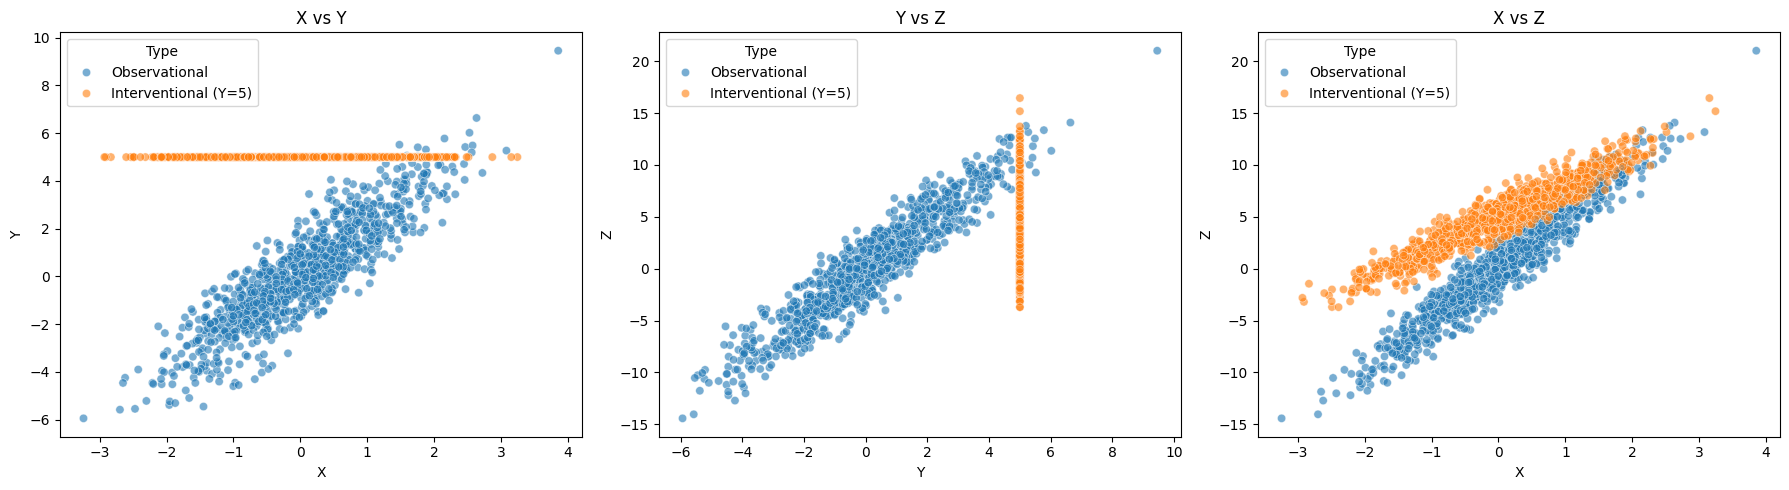

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

def generate_data(n_samples=1000, intervention=None):
    # Exogenous noise variables
    U_X = np.random.normal(0, 1, n_samples)
    U_Y = np.random.normal(0, 1, n_samples)
    U_Z = np.random.normal(0, 1, n_samples)

    # Structural assignments
    X = U_X

    if intervention == 'Y=5':
        Y = np.full(n_samples, 5.0)  # Mutilated assignment
    else:
        Y = 2 * X + U_Y              # Observational assignment

    Z = Y + 3 * X + U_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

# Verification
obs_df = generate_data()
int_df = generate_data(intervention='Y=5')

# Add a column to identify the dataset
obs_df['Type'] = 'Observational'
int_df['Type'] = 'Interventional (Y=5)'
combined_df = pd.concat([obs_df, int_df], ignore_index=True)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X vs Y
sns.scatterplot(data=combined_df, x='X', y='Y', hue='Type', alpha=0.6, ax=axes[0])
axes[0].set_title('X vs Y')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Y vs Z
sns.scatterplot(data=combined_df, x='Y', y='Z', hue='Type', alpha=0.6, ax=axes[1])
axes[1].set_title('Y vs Z')
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')

# X vs Z
sns.scatterplot(data=combined_df, x='X', y='Z', hue='Type', alpha=0.6, ax=axes[2])
axes[2].set_title('X vs Z')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Z')

plt.tight_layout()
plt.savefig('causal_data_plots.png', dpi=300)
print("Plots saved successfully as causal_data_plots.png")

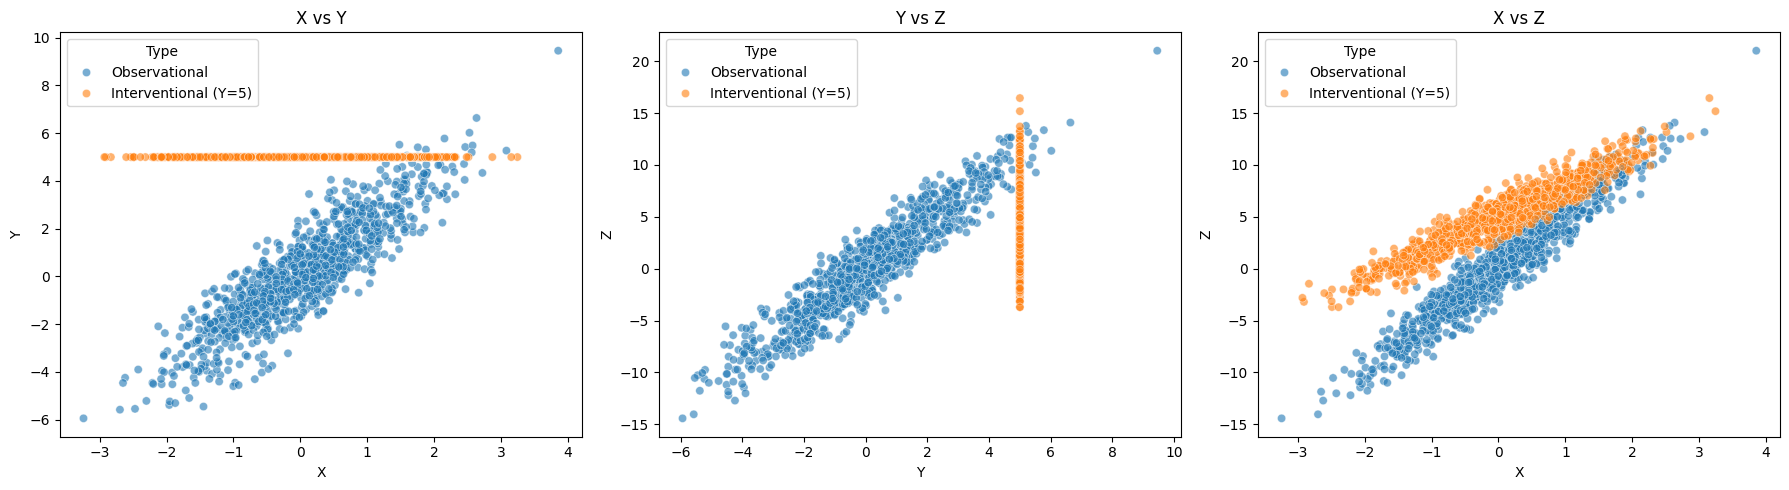

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

def generate_data(n_samples=1000, intervention=None):
    U_X = np.random.normal(0, 1, n_samples)
    U_Y = np.random.normal(0, 1, n_samples)
    U_Z = np.random.normal(0, 1, n_samples)

    X = U_X
    if intervention == 'Y=5':
        Y = np.full(n_samples, 5.0)
    else:
        Y = 2 * X + U_Y

    Z = Y + 3 * X + U_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

obs_df = generate_data()
int_df = generate_data(intervention='Y=5')

# Labeling and combining for plotting
obs_df['Type'] = 'Observational'
int_df['Type'] = 'Interventional (Y=5)'
combined_df = pd.concat([obs_df, int_df], ignore_index=True)

# Plotting setup
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# X vs Y
sns.scatterplot(data=combined_df, x='X', y='Y', hue='Type', alpha=0.6, ax=axes[0])
axes[0].set_title('X vs Y')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Y vs Z
sns.scatterplot(data=combined_df, x='Y', y='Z', hue='Type', alpha=0.6, ax=axes[1])
axes[1].set_title('Y vs Z')
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')

# X vs Z
sns.scatterplot(data=combined_df, x='X', y='Z', hue='Type', alpha=0.6, ax=axes[2])
axes[2].set_title('X vs Z')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Z')

plt.tight_layout()
plt.savefig('causal_data_plots.png', dpi=300)

Plots saved successfully as causal_loops_plots.png


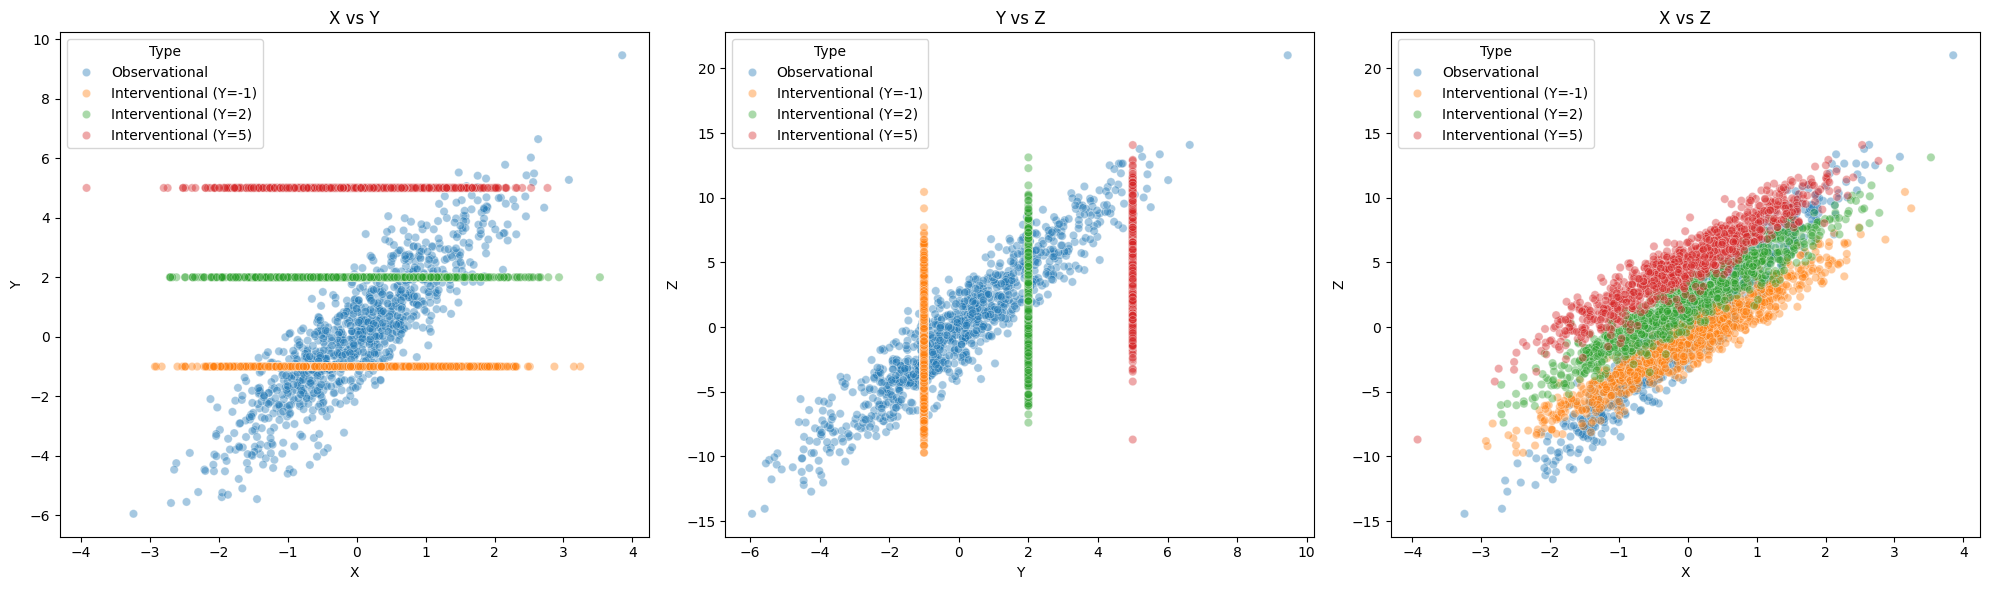

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

def generate_data(n_samples=1000, intervention=None):
    U_X = np.random.normal(0, 1, n_samples)
    U_Y = np.random.normal(0, 1, n_samples)
    U_Z = np.random.normal(0, 1, n_samples)

    X = U_X

    if intervention is not None:
        # Expected intervention format like 'Y=-1', 'Y=2', 'Y=5'
        val = float(intervention.split('=')[1])
        Y = np.full(n_samples, val)
    else:
        Y = 2 * X + U_Y

    Z = Y + 3 * X + U_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z})

# Generate observational data
obs_df = generate_data()
obs_df['Type'] = 'Observational'

dfs = [obs_df]
for y_val in [-1, 2, 5]:
    int_df = generate_data(intervention=f'Y={y_val}')
    int_df['Type'] = f'Interventional (Y={y_val})'
    dfs.append(int_df)

combined_df = pd.concat(dfs, ignore_index=True)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# X vs Y
sns.scatterplot(data=combined_df, x='X', y='Y', hue='Type', alpha=0.4, ax=axes[0], palette='tab10')
axes[0].set_title('X vs Y')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Y vs Z
sns.scatterplot(data=combined_df, x='Y', y='Z', hue='Type', alpha=0.4, ax=axes[1], palette='tab10')
axes[1].set_title('Y vs Z')
axes[1].set_xlabel('Y')
axes[1].set_ylabel('Z')

# X vs Z
sns.scatterplot(data=combined_df, x='X', y='Z', hue='Type', alpha=0.4, ax=axes[2], palette='tab10')
axes[2].set_title('X vs Z')
axes[2].set_xlabel('X')
axes[2].set_ylabel('Z')

plt.tight_layout()
plt.savefig('causal_loops_plots.png', dpi=300)
print("Plots saved successfully as causal_loops_plots.png")

Grid plot created successfully.


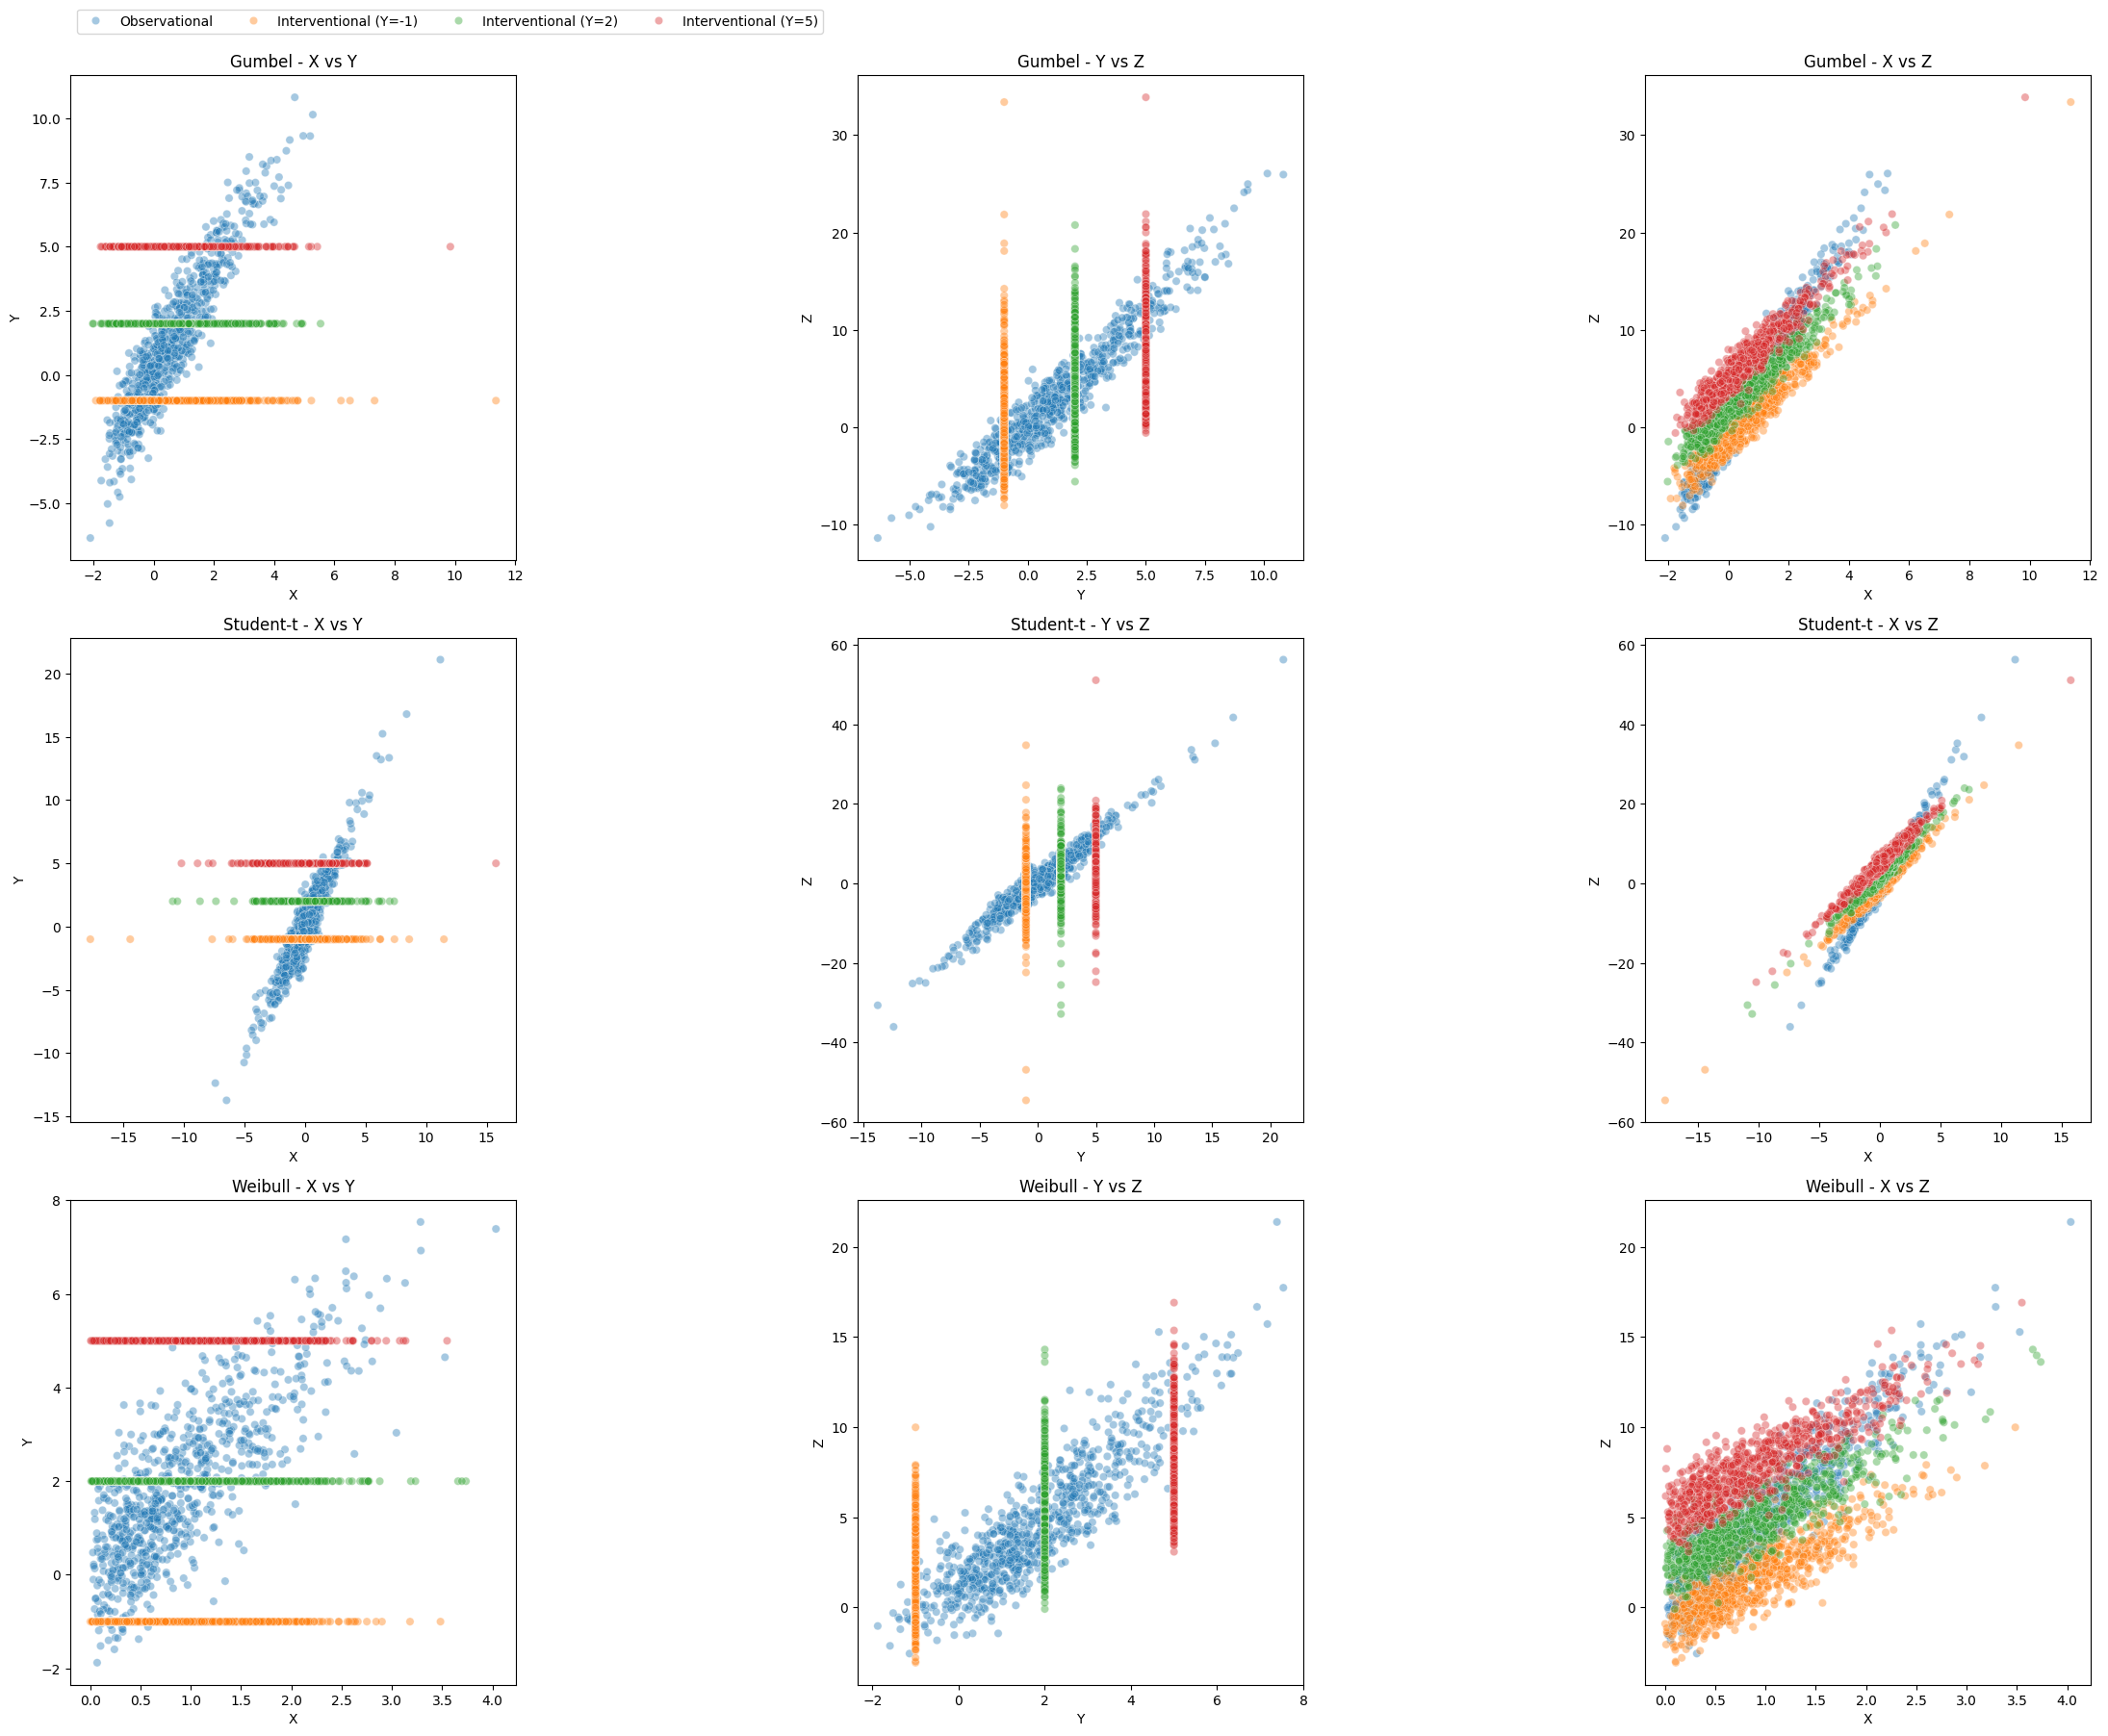

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set random seed for reproducibility
np.random.seed(42)

def generate_custom_data(n_samples=1000, dist_type='gumbel', intervention=None):
    # Select distribution for U_X
    if dist_type == 'gumbel':
        U_X = np.random.gumbel(loc=0.0, scale=1.0, size=n_samples)
    elif dist_type == 'student-t':
        U_X = np.random.standard_t(df=3, size=n_samples) # Heavy tails
    elif dist_type == 'weibull':
        U_X = np.random.weibull(a=1.5, size=n_samples)   # Shape parameter 1.5
    else:
        U_X = np.random.normal(0, 1, n_samples)

    # Standard normal for the other noise terms to isolate the U_X effect
    U_Y = np.random.normal(0, 1, n_samples)
    U_Z = np.random.normal(0, 1, n_samples)

    X = U_X

    if intervention is not None:
        val = float(intervention.split('=')[1])
        Y = np.full(n_samples, val)
    else:
        Y = 2 * X + U_Y

    Z = Y + 3 * X + U_Z
    return pd.DataFrame({'X': X, 'Y': Y, 'Z': Z, 'Distribution': dist_type})

# Generate data across combinations
all_dfs = []
distributions = ['gumbel', 'student-t', 'weibull']
interventions = [None, 'Y=-1', 'Y=2', 'Y=5']

for dist in distributions:
    for inter in interventions:
        df = generate_custom_data(n_samples=800, dist_type=dist, intervention=inter)
        if inter is None:
            df['Type'] = 'Observational'
        else:
            df['Type'] = f'Interventional ({inter})'
        all_dfs.append(df)

master_df = pd.concat(all_dfs, ignore_index=True)

# Plotting a grid: 3 rows (Distributions) x 3 columns (Scatter plots)
fig, axes = plt.subplots(3, 3, figsize=(22, 18))

for i, dist in enumerate(distributions):
    sub_df = master_df[master_df['Distribution'] == dist]

    # X vs Y
    sns.scatterplot(data=sub_df, x='X', y='Y', hue='Type', alpha=0.4, ax=axes[i, 0], palette='tab10', legend=(i==0))
    axes[i, 0].set_title(f'{dist.capitalize()} - X vs Y')

    # Y vs Z
    sns.scatterplot(data=sub_df, x='Y', y='Z', hue='Type', alpha=0.4, ax=axes[i, 1], palette='tab10', legend=False)
    axes[i, 1].set_title(f'{dist.capitalize()} - Y vs Z')

    # X vs Z
    sns.scatterplot(data=sub_df, x='X', y='Z', hue='Type', alpha=0.4, ax=axes[i, 2], palette='tab10', legend=False)
    axes[i, 2].set_title(f'{dist.capitalize()} - X vs Z')

# Move legend to a nice spot if needed, or rely on the subplot layout
axes[0, 0].legend(loc='upper left', bbox_to_anchor=(0, 1.15), ncol=4)
plt.tight_layout()
plt.savefig('causal_advanced_dists.png', dpi=300)
print("Grid plot created successfully.")

In [7]:
import numpy as np
import scipy.stats as stats

# True Mechanism: X -> Y (Nonlinear relationship)
X = np.random.uniform(-3, 3, 1000)
Y = X**3 + np.random.normal(0, 1, 1000)  # Additive Noise

# Forward Fit (Correct Direction): Test if Residuals (Y - f(X)) independent of X
res_forward = Y - np.polyval(np.polyfit(X, Y, 3), X)
p_forward = stats.pearsonr(X, res_forward)[1] # High p-value (Independent)

# Reverse Fit (Incorrect Direction): Test if Residuals (X - g(Y)) independent of Y
res_reverse = X - np.polyval(np.polyfit(Y, X, 3), Y)
p_reverse = stats.pearsonr(Y, res_reverse)[1] # Extremely low p-value (Dependent!)

Forward P: 0.9999999999999608, Reverse P: 0.9999999999999273


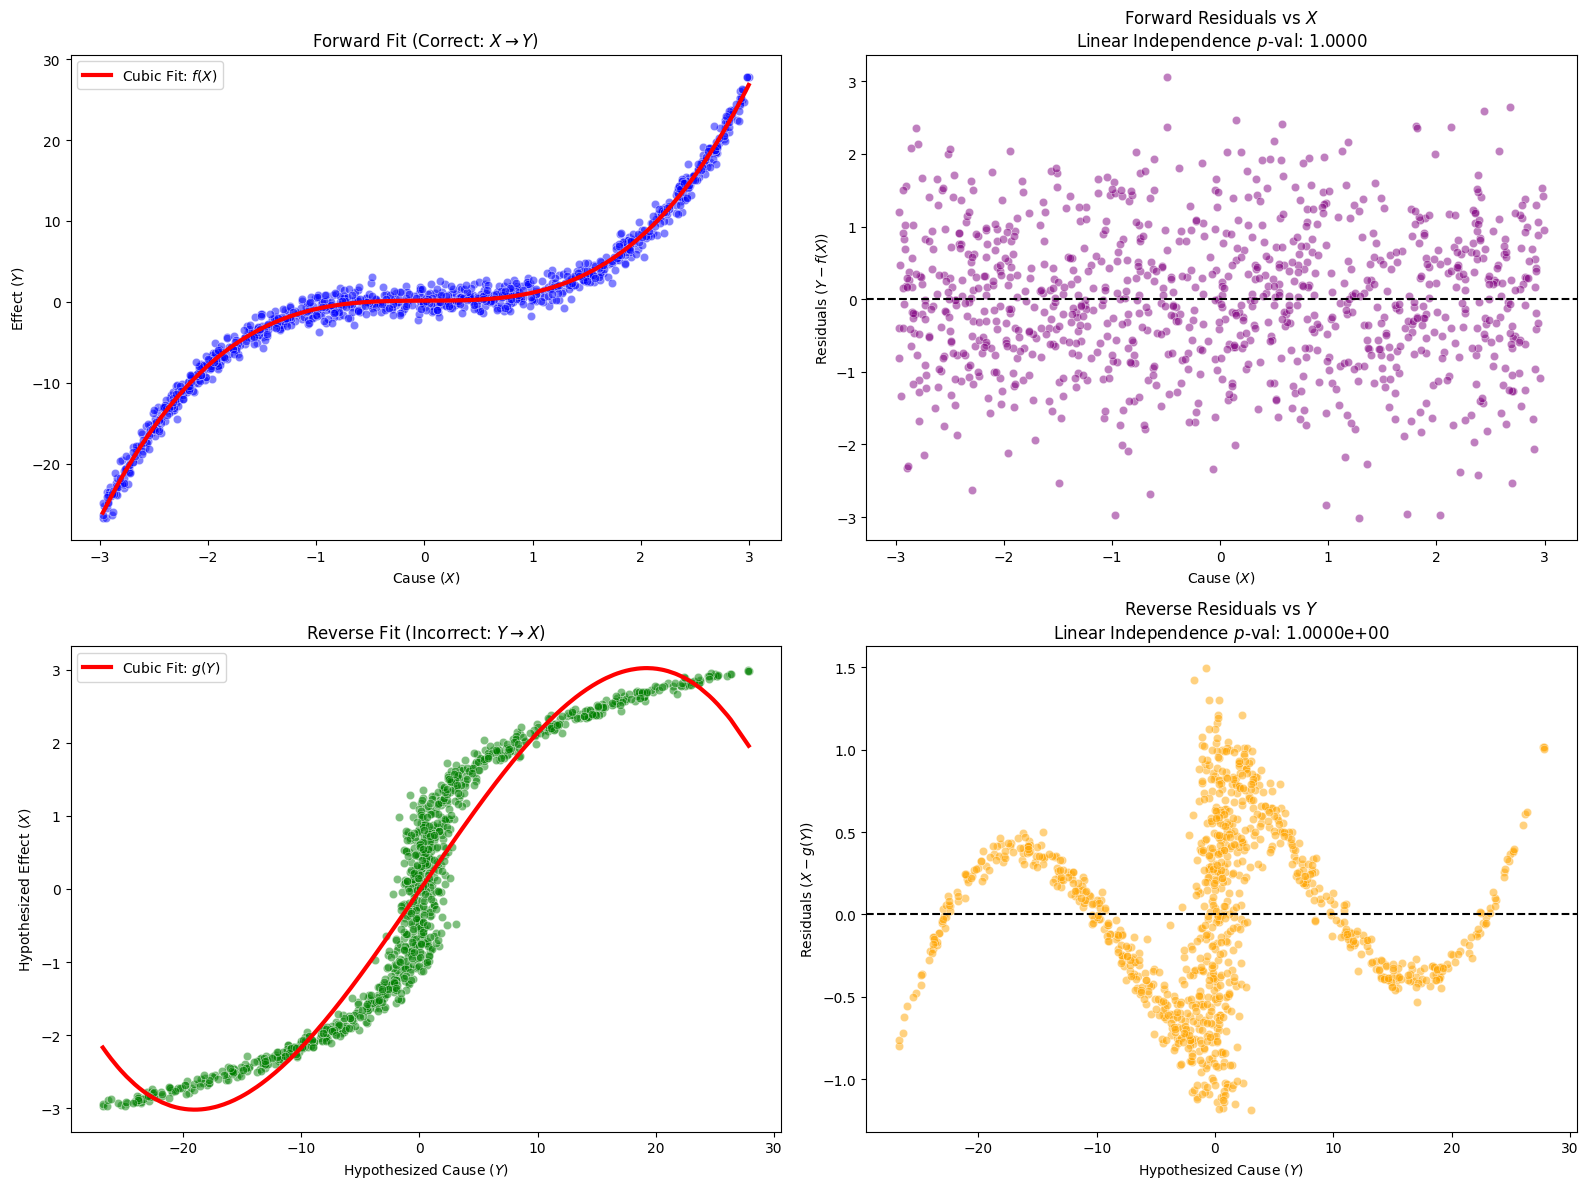

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set seed for consistency
np.random.seed(42)

# True Mechanism: X -> Y (Nonlinear relationship)
X = np.random.uniform(-3, 3, 1000)
Y = X**3 + np.random.normal(0, 1, 1000)

# Forward Fit (X -> Y)
poly_forward = np.polyfit(X, Y, 3)
y_pred_forward = np.polyval(poly_forward, X)
res_forward = Y - y_pred_forward
p_forward_linear = stats.pearsonr(X, res_forward)[1]
# Use a non-linear independence test (like HSIC or a distance correlation proxy, or simply a trend test on squared residuals)
# For visualization, we will look at the scatter of residuals.
# Let's also compute Spearman to check for monotonic patterns
p_forward_spearman = stats.spearmanr(X, res_forward)[1]

# Reverse Fit (Y -> X)
poly_reverse = np.polyfit(Y, X, 3)
x_pred_reverse = np.polyval(poly_reverse, Y)
res_reverse = X - x_pred_reverse
p_reverse_linear = stats.pearsonr(Y, res_reverse)[1]
p_reverse_spearman = stats.spearmanr(Y, res_reverse)[1]

# Plotting
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Forward Fit: X vs Y with regression line
sns.scatterplot(x=X, y=Y, alpha=0.5, color='blue', ax=axes[0, 0])
sort_idx = np.argsort(X)
axes[0, 0].plot(X[sort_idx], y_pred_forward[sort_idx], color='red', lw=3, label='Cubic Fit: $f(X)$')
axes[0, 0].set_title('Forward Fit (Correct: $X \\rightarrow Y$)')
axes[0, 0].set_xlabel('Cause ($X$)')
axes[0, 0].set_ylabel('Effect ($Y$)')
axes[0, 0].legend()

# 2. Forward Residuals: X vs Residuals
sns.scatterplot(x=X, y=res_forward, alpha=0.5, color='purple', ax=axes[0, 1])
axes[0, 1].axhline(0, color='black', linestyle='--')
axes[0, 1].set_title(f'Forward Residuals vs $X$\nLinear Independence $p$-val: {p_forward_linear:.4f}')
axes[0, 1].set_xlabel('Cause ($X$)')
axes[0, 1].set_ylabel('Residuals ($Y - f(X)$)')

# 3. Reverse Fit: Y vs X with regression line
sns.scatterplot(x=Y, y=X, alpha=0.5, color='green', ax=axes[1, 0])
sort_idx_y = np.argsort(Y)
axes[1, 0].plot(Y[sort_idx_y], x_pred_reverse[sort_idx_y], color='red', lw=3, label='Cubic Fit: $g(Y)$')
axes[1, 0].set_title('Reverse Fit (Incorrect: $Y \\rightarrow X$)')
axes[1, 0].set_xlabel('Hypothesized Cause ($Y$)')
axes[1, 0].set_ylabel('Hypothesized Effect ($X$)')
axes[1, 0].legend()

# 4. Reverse Residuals: Y vs Residuals
sns.scatterplot(x=Y, y=res_reverse, alpha=0.5, color='orange', ax=axes[1, 1])
axes[1, 1].axhline(0, color='black', linestyle='--')
axes[1, 1].set_title(f'Reverse Residuals vs $Y$\nLinear Independence $p$-val: {p_reverse_linear:.4e}')
axes[1, 1].set_xlabel('Hypothesized Cause ($Y$)')
axes[1, 1].set_ylabel('Residuals ($X - g(Y)$)')

plt.tight_layout()
plt.savefig('anm_causal_direction.png', dpi=300)
print(f"Forward P: {p_forward_linear}, Reverse P: {p_reverse_linear}")